In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


import time
import math
import random
import re
import os
import sys


from utils.util import find_files_with_extension
from utils.util import  get_dataframe_from_filepath,calculate_statistics, extract_unique_mbps_and_ms
from utils.util import remove_outliers_iqr, comma_format, create_directory_if_not_exists,print_rtt_stats,save_rtt_stats,return_rtt_stats
from utils.udp_util import extract_udp_prague_to_dataframe

In [29]:
# Load data
mainpth="../data/udp_data_2025-04-11"
mainpth="../data/udp_data_2025-04-27"
mainpth="../data/udp_data_2025-04-28"


graph_directory = os.path.join(mainpth, "Graphs")
create_directory_if_not_exists(graph_directory)

stats_directory = os.path.join(mainpth, "Stats")
create_directory_if_not_exists(stats_directory)


folderpaths = [mainpth+'/server_data', mainpth+'/client1_data', mainpth+'/client2_data']
filenames, filepaths, filedict = find_files_with_extension(folderpaths, '')


# Call the function and print unique combinations
unique_combinations = extract_unique_mbps_and_ms(folderpaths)
print("Unique Mbps and ms Combinations:")
for mbps, ms in sorted(unique_combinations):
    print(f'{mbps} Mbps, {ms} ms')




Directory already exists: ../data/udp_data_2025-04-28\Graphs
Directory already exists: ../data/udp_data_2025-04-28\Stats
Unique Mbps and ms Combinations:
8 Mbps, 10 ms


In [30]:
unique_scenarios_dict_v2 = {}
for mbps, ms in unique_combinations:
    scenario_search = f"{mbps}Mbps_{ms}ms"
    for index in range(len(filenames)):
        if scenario_search in filenames[index]:
            print(f"Found {scenario_search} in {filenames[index]}")
            if scenario_search in unique_scenarios_dict_v2:
                unique_scenarios_dict_v2[scenario_search].append(filedict[filenames[index]])
            else:
                unique_scenarios_dict_v2[scenario_search]=[filedict[filenames[index]]]
            


Found 8Mbps_10ms in 1_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap
Found 8Mbps_10ms in 1_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log
Found 8Mbps_10ms in 2_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap
Found 8Mbps_10ms in 2_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log
Found 8Mbps_10ms in 3_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap
Found 8Mbps_10ms in 3_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log
Found 8Mbps_10ms in udp_prague_receiver_1_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in udp_prague_receiver_2_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in udp_prague_receiver_3_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in udp_prague_sender_1_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in udp_prague_sender_2_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in udp_prague_sender_3_dualpi2_8Mbps_10ms_ecn_udp.txt
Found 8Mbps_10ms in 1_dualpi2_8Mbps_10ms_ecn_udp_cubic_src1.em1.pcap
Found 8Mbps_10ms in 1_dualpi2_8Mbps_10ms_ecn_udp_cubic_src1.siftr.log
Found 8Mbps_10ms in 2_dualpi2_

In [31]:
# unique_scenarios_dict_v2['100Mbps_10ms']

In [32]:
from utils.plotter import  plot_siftr_graph

In [33]:
for scenario in unique_scenarios_dict_v2.keys():
    index = "1_dualpi2"

    search_list = ["1_dualpi2", "log", "txt"]

    print()
    print("Start New Scenario")
    # print(scenario)
    # print(unique_scenarios_dict_v2[scenario])

    print("Scenario", scenario)
    

    my_list = unique_scenarios_dict_v2[scenario]


    for i, item in enumerate(my_list, start=0):
        print(f"{i}. {item}")


    print(unique_scenarios_dict_v2[scenario])
    print("utf", unique_scenarios_dict_v2[scenario][4])
    print("ttf", unique_scenarios_dict_v2[scenario][13])



Start New Scenario
Scenario 8Mbps_10ms
0. ../data/udp_data_2025-04-28/server_data\1_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap
1. ../data/udp_data_2025-04-28/server_data\1_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log
2. ../data/udp_data_2025-04-28/server_data\2_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap
3. ../data/udp_data_2025-04-28/server_data\2_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log
4. ../data/udp_data_2025-04-28/server_data\3_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap
5. ../data/udp_data_2025-04-28/server_data\3_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log
6. ../data/udp_data_2025-04-28/server_data\udp_prague_receiver_1_dualpi2_8Mbps_10ms_ecn_udp.txt
7. ../data/udp_data_2025-04-28/server_data\udp_prague_receiver_2_dualpi2_8Mbps_10ms_ecn_udp.txt
8. ../data/udp_data_2025-04-28/server_data\udp_prague_receiver_3_dualpi2_8Mbps_10ms_ecn_udp.txt
9. ../data/udp_data_2025-04-28/server_data\udp_prague_sender_1_dualpi2_8Mbps_10ms_ecn_udp.txt
10. ../data/udp_data_2025-04-28/server_da

In [34]:
def filter_strings_by_substrings(strings, sub_strings):
    result = []
    for s in strings:
        if all(sub in s for sub in sub_strings):
            result.append(s)
    return result


In [35]:
unique_scenarios_dict_v2

{'8Mbps_10ms': ['../data/udp_data_2025-04-28/server_data\\1_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap',
  '../data/udp_data_2025-04-28/server_data\\1_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log',
  '../data/udp_data_2025-04-28/server_data\\2_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap',
  '../data/udp_data_2025-04-28/server_data\\2_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log',
  '../data/udp_data_2025-04-28/server_data\\3_dualpi2_8Mbps_10ms_ecn_udp_dsthost.em1.pcap',
  '../data/udp_data_2025-04-28/server_data\\3_dualpi2_8Mbps_10ms_ecn_udp_dsthost.siftr.log',
  '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_1_dualpi2_8Mbps_10ms_ecn_udp.txt',
  '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_2_dualpi2_8Mbps_10ms_ecn_udp.txt',
  '../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_3_dualpi2_8Mbps_10ms_ecn_udp.txt',
  '../data/udp_data_2025-04-28/server_data\\udp_prague_sender_1_dualpi2_8Mbps_10ms_ecn_udp.txt',
  '../data/udp_data_2025-04-28/server

In [ ]:
for scenario in unique_scenarios_dict_v2.keys():
    index = "1_dualpi2"

    search_list_tcp = [index, "log", "src"]
    filtered_tcp = filter_strings_by_substrings(unique_scenarios_dict_v2[scenario], search_list_tcp)

    search_list_udp = [index, "udp_prague_receiver"]
    filtered_udp = filter_strings_by_substrings(unique_scenarios_dict_v2[scenario], search_list_udp)

    print()
    print("Start New Scenario")
    print("Scenario", scenario)
    print(filtered_tcp)
    print(filtered_udp)


Start New Scenario
Scenario 8Mbps_10ms
['../data/udp_data_2025-04-28/client1_data\\1_dualpi2_8Mbps_10ms_ecn_udp_cubic_src1.siftr.log', '../data/udp_data_2025-04-28/client2_data\\1_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src2.siftr.log']
['../data/udp_data_2025-04-28/server_data\\udp_prague_receiver_1_dualpi2_8Mbps_10ms_ecn_udp.txt']
../data/udp_data_2025-04-28/client2_data\1_dualpi2_8Mbps_10ms_ecn_udp_dctcp_src2.siftr.log


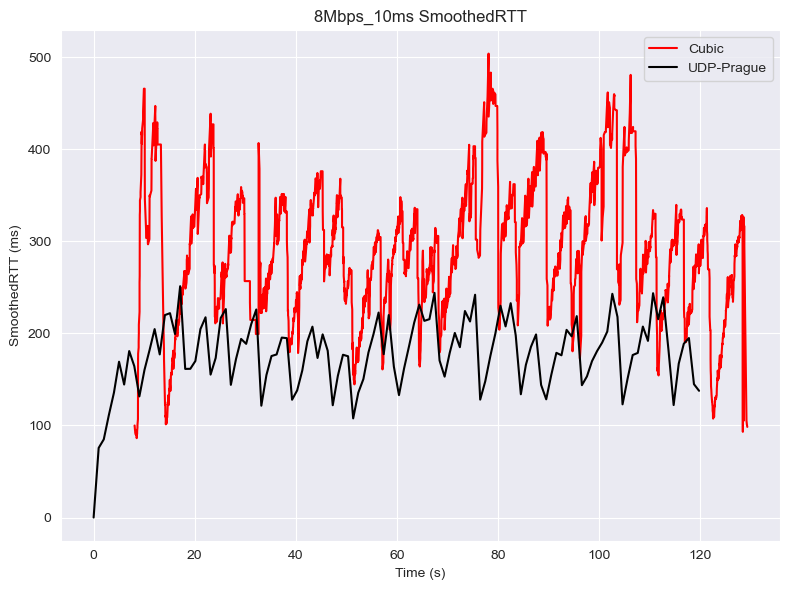

In [50]:
for scenario in unique_scenarios_dict_v2.keys():
    index = "1_dualpi2"

    search_list_tcp = [index, "log", "src"]
    filtered_tcp = filter_strings_by_substrings(unique_scenarios_dict_v2[scenario], search_list_tcp)

    search_list_udp = [index, "udp_prague_receiver"]
    filtered_udp = filter_strings_by_substrings(unique_scenarios_dict_v2[scenario], search_list_udp)

    print()
    print("Start New Scenario")
    print("Scenario", scenario)
    print(filtered_tcp)
    print(filtered_udp)

    udp_traffic = filtered_udp[0]
    utf = extract_udp_prague_to_dataframe(udp_traffic)

    tcp_traffic = filtered_tcp[1]
    ttf = get_dataframe_from_filepath(tcp_traffic)
    ttf = ttf[ttf['ForeignPort'] == "5102"]

    utf.rename(columns={'RTT_ms': 'SmoothedRTT'}, inplace=True)



        # Define paths
    paths = {
        "Cubic": ttf,
        "UDP-Prague": utf
    }

    plot_siftr_graph(paths=paths,
                    ycolumn="SmoothedRTT",
                    title=f"{scenario} SmoothedRTT",
                    xlabel="Time (s)",
                    ylabel="SmoothedRTT (ms)",
                    filename=f'{scenario}_SmoothedRTT',
                    graph_directory=graph_directory,
    )


In [46]:
os.path.getsize(filtered_tcp[0])


17977

In [45]:
os.path.getsize(filtered_tcp[1])

3280013